# COGs with real data — an end-to-end workflow

This notebook exercises the **full COG surface** of pyramids against the real rasters that
ship with the repository:

- `examples/data/geotiff/noah-precipitation-1979.tif` — a global 4-band NOAH precipitation
  grid (EPSG:4326, 360×720), big enough to carry internal overviews.
- `examples/data/dem/DEM5km_Rhine_burned_fill.tif` — a Rhine-basin DEM in a projected CRS
  (EPSG:4647), used for the web-optimized / XYZ-tile examples.
- `examples/data/geotiff/rhine/Qtot_*.tif` — a 10-step daily runoff series, exported as a
  COG stack.

It is **offline** (no network) and runs in CI under `pytest --nbval-lax`.

## Setup

In [1]:
%matplotlib inline

import math
import tempfile
from pathlib import Path

from pyproj import Transformer

from pyramids.dataset import Dataset, DatasetCollection, cog
from pyramids.dataset.cog import validate

# Resolve the bundled example data whether the kernel runs from the notebook
# directory (CI) or the repo root.
DATA = Path("../../../examples/data")
work = Path(tempfile.mkdtemp(prefix="pyramids-cog-real-"))
print("data:", DATA.resolve())
print("work:", work)

data: C:\gdrive\algorithms\serapeum-github-org\repos\gis\pyramids\examples\data
work: C:\Users\main\AppData\Local\Temp\pyramids-cog-real-_oywhxx5


## 1. Write a real raster as a COG, then inspect & validate it

The NOAH precipitation grid is a 4-band float global raster. `to_cog` resolves the
predictor (float → 3) and overview resampling (continuous → `average`) from its dtype.

In [2]:
noah = Dataset.read_file(DATA / "geotiff" / "noah-precipitation-1979.tif")
print("source:", noah.epsg, f"{noah.rows}x{noah.columns}", noah.band_count, "bands")

out = noah.to_cog(work / "noah_cog.tif")
info = Dataset.read_file(out).cog_info()
print("compression:", info.compression, "predictor:", info.predictor)
print("blocksize:  ", info.blocksize, "dtype:", info.dtype)
print("overviews:  ", [o.decimation for o in info.overviews])

report = validate(out)
print("valid COG:", report.is_valid, "| errors:", report.errors)

source: 4326 360x720 4 bands
compression: DEFLATE predictor: 3
blocksize:   (512, 512) dtype: Float32
overviews:   [2]
valid COG: True | errors: []


Plot the first band of the source `noah` grid to see the global precipitation field we just wrote as a COG.

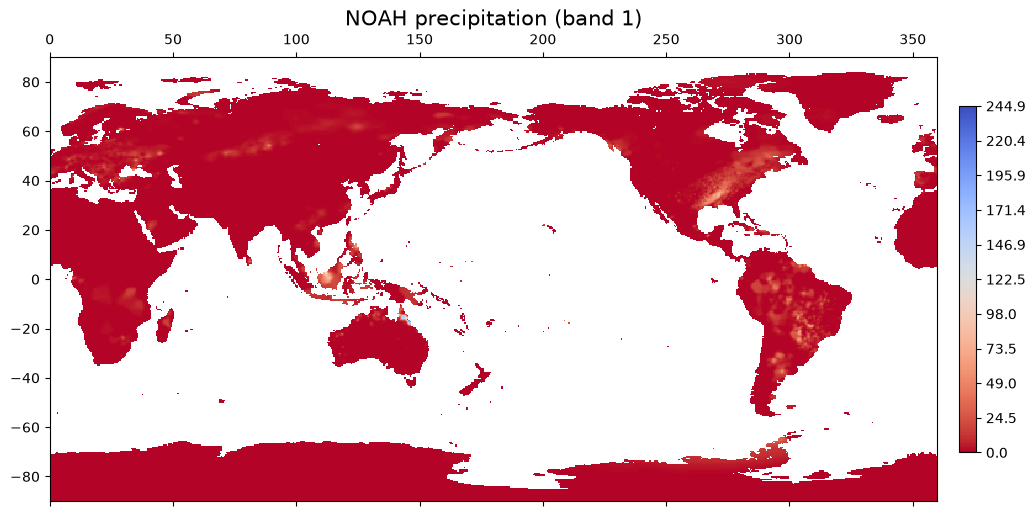

In [3]:
noah.plot(band=0, title="NOAH precipitation (band 1)")

## 2. Named compression profiles

In [4]:
zstd = noah.to_cog(work / "noah_zstd.tif", compression="zstd")
print("compression=zstd ->", Dataset.read_file(zstd).cog_info().compression)

compression=zstd -> ZSTD


## 3. Partial / overview-decimated reads

Coordinates are derived from the raster's own bounds, so this works for any real extent.
Requesting a smaller output size makes GDAL serve the data from the nearest overview.

In [5]:
minx, miny, maxx, maxy = noah.bbox
w, h = maxx - minx, maxy - miny

# Whole-image thumbnail (long edge <= 128 px):
thumb = noah.preview(max_size=128, band=0)
print("thumbnail:", thumb.shape)

# Central quarter window, decimated to 256x256:
sub = (minx + 0.25 * w, miny + 0.25 * h, minx + 0.75 * w, miny + 0.75 * h)
part = noah.read_part(sub, dst_width=256, dst_height=256, bbox_crs=noah.epsg, band=0)
print("window:   ", part.shape)

# Sample the centre coordinate:
value = noah.point(minx + 0.5 * w, miny + 0.5 * h, point_crs=noah.epsg, band=0)
print("centre value:", float(value))

thumbnail: (64, 128)
window:    (256, 256)
centre value: -9.969209968386869e+36


## 4. Encode to in-memory bytes (object-store upload)

In [6]:
blob = noah.to_cog_bytes(compression="zstd")
print("bytes:", len(blob), "| TIFF marker:", blob[:2])
# e.g. boto3: s3.put_object(Bucket=..., Key="noah.tif", Body=blob)

bytes: 860652 | TIFF marker: b'II'


## 5. Band subset, dtype cast, NoData, tags & metadata

Take the first three of NOAH's four bands, cast to int16, set NoData, and attach tags —
all on an in-memory copy, so the source dataset is never mutated.

In [7]:
rgb = noah.to_cog(
    work / "noah_rgb.tif",
    bands=cog.BandSelection(
        indexes=[0, 1, 2],  # select + reorder bands (0-based)
        out_dtype="int16",  # predictor re-resolves to 2 for the cast
        nodata=-9999,
    ),
    tags=cog.Tags(
        band_tags={0: {"name": "precip_band_1"}},
        metadata={"source": "NOAH-1979", "pipeline": "cog-real-data-notebook"},
    ),
)
rgb_info = Dataset.read_file(rgb).cog_info()
print(
    "bands:",
    rgb_info.band_count,
    "dtype:",
    rgb_info.dtype,
    "predictor:",
    rgb_info.predictor,
)
print("band-1 tag:", rgb_info.band_tags[1].get("name"))

bands: 3 dtype: Int16 predictor: 2
band-1 tag: precip_band_1


## 6. Web-optimized COG (reproject to Web-Mercator)

The Rhine DEM is in a projected CRS (EPSG:4647). `tiling=cog.Tiling(scheme="GoogleMapsCompatible")`
reprojects to EPSG:3857 and aligns overviews to the Web-Mercator zoom grid, ready for a
tile server.

In [8]:
dem = Dataset.read_file(DATA / "dem" / "DEM5km_Rhine_burned_fill.tif")
print("DEM source CRS:", dem.epsg)

web = dem.to_cog(work / "dem_web.tif", tiling=cog.Tiling(scheme="GoogleMapsCompatible"))
print("web-optimized CRS:", Dataset.read_file(web).epsg)

DEM source CRS: 4647


web-optimized CRS: 3857


Plot the Rhine `dem` band before reprojecting it to Web-Mercator — the elevation surface in its native
projected CRS.

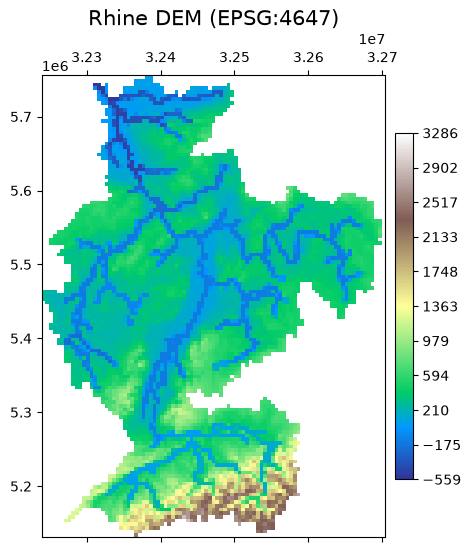

In [9]:
dem.plot(band=0, title="Rhine DEM (EPSG:4647)", cmap="terrain")

## 7. Read a Web-Mercator XYZ tile

Compute the slippy-map tile that contains the DEM's centre, then read it. `read_tile`
reprojects the tile's EPSG:3857 bounds back to the dataset CRS — no `morecantile` needed.

In [10]:
cx, cy = (dem.bbox[0] + dem.bbox[2]) / 2, (dem.bbox[1] + dem.bbox[3]) / 2
lon, lat = Transformer.from_crs(dem.epsg, 4326, always_xy=True).transform(cx, cy)
z = 6
n = 2**z
xt = int((lon + 180.0) / 360.0 * n)
yt = int((1.0 - math.asinh(math.tan(math.radians(lat))) / math.pi) / 2.0 * n)
print(f"DEM centre lon/lat = {lon:.2f}, {lat:.2f}  ->  tile z{z}/{xt}/{yt}")

tile = dem.read_tile(z, xt, yt, tilesize=256)
print("tile shape:", tile.shape)

DEM centre lon/lat = 8.61, 49.14  ->  tile z6/33/21
tile shape: (256, 256)


## 8. Export a real time series as a COG stack

The `rhine/` folder holds a 10-step daily runoff series. `DatasetCollection.to_cog_stack`
writes one COG per time slice.

In [11]:
dc = DatasetCollection.read_multiple_files(DATA / "geotiff" / "rhine", with_order=False)
dc.open_multi_dataset(band=0)
paths = dc.to_cog_stack(
    work / "rhine_cogs",
    pattern="Qtot_{i:02d}.tif",
    name="Qtot",
    compression=cog.Compression(compress="DEFLATE"),
)
print("slices written:", len(paths), "| time_length:", dc.time_length)
print("first slice is a valid COG:", validate(paths[0]).is_valid)

slices written:

 10 | time_length: 10
first slice is a valid COG: True


C:\Users\main\AppData\Local\Temp\ipykernel_2056\3236988729.py:1: DeprecationWarning: DatasetCollection.read_multiple_files is deprecated; use from_files(path, glob=..., date_format=...) instead.
  dc = DatasetCollection.read_multiple_files(DATA / "geotiff" / "rhine", with_order=False)


Plot the first band of the `dc` runoff collection to visualize one time slice of the daily series exported as a
COG stack.

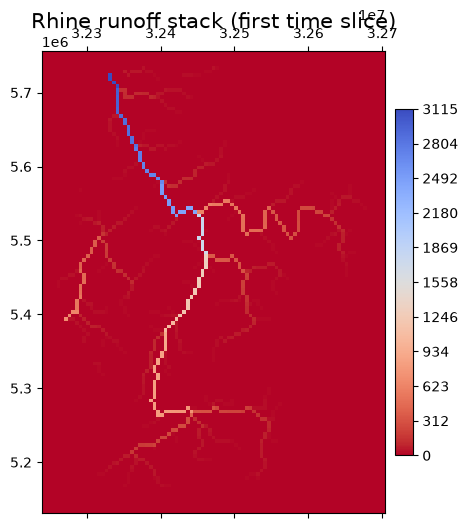

In [12]:
dc.iloc(0).plot(band=0, title="Rhine runoff stack (first time slice)")

## 9. Command line

The same workflow from the shell via the `pyramids cog` command group (here driven
in-process).

In [13]:
from pyramids.cli import main

print("validate exit code:", main(["cog", "validate", str(out)]))
print("--- info ---")
main(["cog", "info", str(out)])

C:\Users\main\AppData\Local\Temp\pyramids-cog-real-_oywhxx5\noah_cog.tif: valid COG
validate exit code: 0
--- info ---
file:        C:\Users\main\AppData\Local\Temp\pyramids-cog-real-_oywhxx5\noah_cog.tif
is_cog:      True
driver:      GTiff
size:        720 x 360 (4 band(s))
dtype:       Float32
crs:         EPSG:4326
resolution:  (0.5, 0.5)
bounds:      (0.0, -90.0, 360.0, 90.0)
compression: DEFLATE
predictor:   3
blocksize:   (512, 512)
overviews:   1
  - level 0: 360 x 180 (1/2)


0